In [1]:

import os 
import sys
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
module_path = os.path.abspath('../')
if module_path not in sys.path:
    sys.path.append(module_path)
from CPU_solver.SystemSolverCPU import SolverCPU



In [10]:
Nx = 100
Ny = 100
L  = 60
H  = 60
chi = H/6 
Q = -5e-2
w0 = 1e-2
x =np.linspace(0,L, Nx, endpoint=0) + L/Nx/2
y =np.linspace(0,H, Ny, endpoint=0) + H/Ny/2

xx, yy = np.meshgrid(x,y)

q_in = -Q/chi*np.where(np.abs(y-H/2)<chi/2, 1, 0)
q_in = (q_in + q_in[::-1])/2
q_out = -np.mean(q_in)

c0 = np.zeros((Nx, Ny))
w = w0*np.ones((Nx, Ny))

config = {
    'grid': {
        'Tmax': 400,
        'Ny': Ny, 
        'Nx': Nx,
        'L': L,
        'H': H,
        'dT': 2,
    },
    'physics': {
        'c0': c0,
        'w': w,
        'beta': 2.5,
        'mu0': 0.001,
        'cmax': 0.635,
        'rho1': 1e3,
        'rho2': 2.7e3,
        'g': 9.8*0,
        'r': 0*1e-3,
    },
    'numerics': {
        'CFL': 0.8,
        'rk_stages': 3,
        'lim_type': 'koren',
        'kappa': -1,
        'WENO_type': 'Z',
        'use_WENO': False,
        'prefer_CG': True,
        'prefer_async_CG': True,
        'async_check_interval': 1,
        'eps': 10**-10,
        'max_iter': 10**5,
    },
    'boundary_conditions': {
        'q_in': q_in,
        'q_out': q_out,
        'c_in_times': np.array([50]),
        'c_in_arr':   np.array([0.45, 0.0]),
    }
}


In [11]:

s = SolverCPU(config)
s.PressureSolver.get_solver_stats()


{'iterations': 384, 'rel_residual': 9.622713786166413e-11, 'converged': True}

In [ ]:
q_out/w0, Q/chi/w0, s.Vst

(-0.08, -0.5, -0.0)

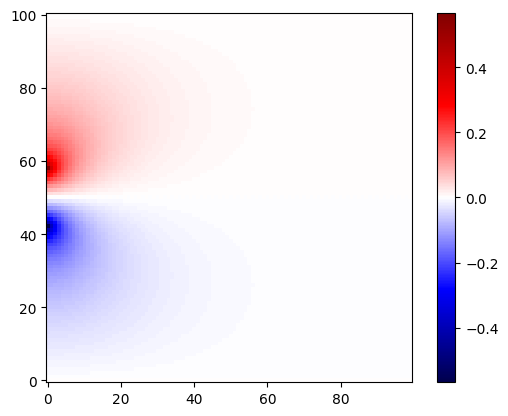

In [12]:
plt.imshow(s.Vy[0], origin="lower", cmap="seismic")
plt.colorbar()

In [38]:
s.solve(s.Tmax)

Solving:   0%|          | 0/200 [00:00<?, ?step/s]

Nt-limit
done


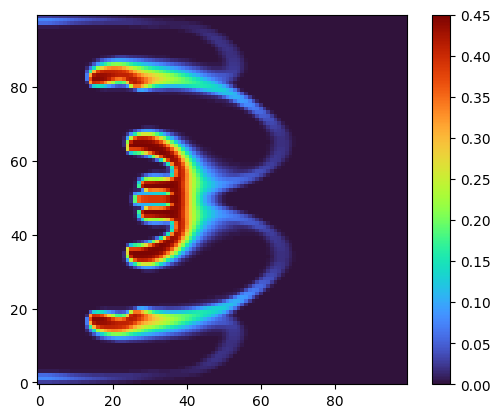

In [39]:
plt.imshow(s.Q[-1]/s.w, origin="lower", cmap="turbo", vmax=s.c_in_arr[0], vmin=0)
plt.colorbar()

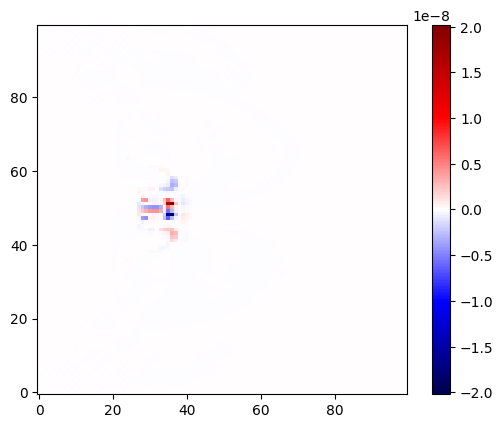

In [40]:
plt.imshow((s.Q[-1]-s.Q[-1,::-1])/s.w, origin="lower", cmap="seismic")
plt.colorbar()